## Calculando imagens do jacobiano de MRIs representativas de cada score, dentro de intervalo de slices previamente selecionado

In [2]:
import os
import SimpleITK as sitk
import ants
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import itk 


In [3]:
import itk
itk.global_default_number_of_threads = 1  # Configura para um único thread, garantindo reprodutibilidade perfeita

In [4]:
def standardize_image(atlas_ref_fname, input_fname):
    """Realiza correspondência de histograma para padronizar a intensidade da imagem de entrada em relação ao atlas."""
    fixed = sitk.ReadImage(atlas_ref_fname, sitk.sitkFloat32)
    moving = sitk.ReadImage(input_fname, sitk.sitkFloat32)

    matcher = sitk.HistogramMatchingImageFilter()
    if fixed.GetPixelID() in (sitk.sitkUInt8, sitk.sitkInt8):
        matcher.SetNumberOfHistogramLevels(128)
    else:
        matcher.SetNumberOfHistogramLevels(512)
    matcher.SetNumberOfMatchPoints(11)
    matcher.ThresholdAtMeanIntensityOn()

    standardized_image = matcher.Execute(moving, fixed)
    return standardized_image

In [5]:
def compute_jacobian_determinant(fix_img, transform_path):
    """Calcula o determinante do Jacobiano a partir da transformação obtida no registro."""
    jacobian = ants.create_jacobian_determinant_image(domain_image=fix_img, tx=transform_path, do_log=False)
    return jacobian

In [6]:
def plot_jacobian(jacobian_image, output_path, patient_id, plane):
    jac_array = jacobian_image.numpy()
    central_slice = jac_array.shape[-1] // 2
    
    plt.figure(figsize=(8, 6))
    plt.imshow(jac_array[:, :, central_slice], cmap="jet", origin="lower")
    plt.colorbar(label="Log-Det Jacobian")
    plt.title(f"Jacobiano - {patient_id} ({plane})")
    # plt.savefig(os.path.join(output_path, f"{patient_id}_jacobian_{plane}.png"))
    plt.close()

In [7]:
import ants
import numpy as np

def compute_mean_displacement_magnitude(displacement_field_slices):
    """
    Calcula a média da magnitude do deslocamento a partir de um campo de deslocamento.
    """
    # Lê o campo de deslocamento

    valid_displacement = displacement_field_slices[~np.isnan(displacement_field_slices).any(axis=-1)]
    
    # Calcula a magnitude dos vetores de deslocamento |u| = sqrt(u_x^2 + u_y^2 + u_z^2)
    displacement_magnitude = np.linalg.norm(valid_displacement, axis=-1)

    # Calcula a média da magnitude
    mean_magnitude = np.mean(displacement_magnitude)

    return mean_magnitude


In [8]:
def calculate_root_mean_square(displacement_field_slices):
    valid_displacement = displacement_field_slices[~np.isnan(displacement_field_slices).any(axis=-1)]
    
    # Calcula a magnitude dos vetores de deslocamento |u| = sqrt(u_x^2 + u_y^2 + u_z^2)
    displacement_magnitude = np.linalg.norm(valid_displacement, axis=-1)

    # Calcula o RMS do displacement field
    rms_magnitude = np.sqrt(np.mean(displacement_magnitude ** 2))

    return rms_magnitude

In [9]:
def calculate_std_deviation(jacobian_slices):
    std_deviation = np.std(jacobian_slices)

    return std_deviation

In [10]:
def calculate_mean_det_jacobian(jacobian_slices):
    mean_jacobian_slices = np.mean(jacobian_slices)

    return mean_jacobian_slices

In [11]:
def calculate_magnitude_variance(displacement_field_slices):
    valid_displacement = displacement_field_slices[~np.isnan(displacement_field_slices).any(axis=-1)]
    
    # Calcula a magnitude dos vetores de deslocamento para cada ponto (em 3D, por exemplo)
    displacement_magnitude = np.linalg.norm(valid_displacement, axis=-1)
    
    # Calcula a variância das magnitudes dos deslocamentos
    magnitude_variance = np.var(displacement_magnitude)

    return magnitude_variance

In [12]:
import numpy as np
from scipy.ndimage import laplace

def calculate_bending_energy(displacement_field):
    # Extraímos as componentes de deslocamento (vx, vy, vz)
    vx = displacement_field[..., 0]
    vy = displacement_field[..., 1]
    vz = displacement_field[..., 2]
    
    # Calculando o Laplaciano para cada componente
    d2vx = laplace(vx)  # Laplaciano de vx
    d2vy = laplace(vy)  # Laplaciano de vy
    d2vz = laplace(vz)  # Laplaciano de vz


    # Derivadas mistas (usando diferenças finitas para as derivadas mistas)
    d2vx_dy = np.gradient(np.gradient(vx, axis=1), axis=0)
    d2vx_dz = np.gradient(np.gradient(vx, axis=2), axis=0)
    d2vy_dz = np.gradient(np.gradient(vy, axis=2), axis=1)

    # Calculando a Bending Energy (BE) como a soma dos quadrados das derivadas
    bending_energy = np.sum(d2vx**2 + d2vy**2 + d2vz**2 + 2 * (d2vx_dy**2 + d2vx_dz**2 + d2vy_dz**2))
    
    return bending_energy




In [13]:
import itk

def compute_strain_tensor_from_file(displacement_field_path, temp_dir, patient_id, fix_img_path):
    # Carregar ou definir o campo de deslocamento como uma imagem ITK
    displacement_field = itk.imread(displacement_field_path)
    fix_img = ants.image_read(fix_img_path)

    # Criar o filtro para calcular o tensor de deformação
    strain_filter = itk.StrainImageFilter.New(Input=displacement_field)
    strain_filter.SetStrainForm(1)
    strain_filter.Update()

    # Obter a imagem resultante do tensor de deformação
    green_lagrange_tensor = strain_filter.GetOutput()

    # Converter para array e reordenar eixos para [X, Y, Z, componentes]
    np_tensor = itk.GetArrayFromImage(green_lagrange_tensor)
    np_tensor = np.transpose(np_tensor, (2, 1, 0, 3))

    # Criar imagem ANTs a partir do array reordenado, preservando metadados
    origin = fix_img.origin
    spacing = fix_img.spacing
    direction = fix_img.direction
    ants_img = ants.from_numpy(np_tensor, origin=origin, spacing=spacing, direction=direction, has_components=True)

    # Salvar a imagem resultante
    output_path = f"{temp_dir}/{patient_id}_strain_tensor.nii.gz"
    ants.image_write(ants_img, output_path)
    print(f"Imagem salva com sucesso como {output_path}")

    return ants_img


In [14]:
def calculate_strain_tensor_features(strain_tensor_slices, patient_id, plane, strain_tensor_features):
    X, Y, Z, _ = strain_tensor_slices.shape  # Pegamos a forma da imagem original
    strain_tensor = np.zeros((X, Y, Z, 3, 3))  # Criamos um array vazio para armazenar as matrizes completas
    print(patient_id)
    print(strain_tensor_slices.shape, np.min(strain_tensor_slices), np.max(strain_tensor_slices))
    # Preenche a matriz simétrica
    strain_tensor[..., 0, 0] = strain_tensor_slices[..., 0]  # ε_xx
    strain_tensor[..., 1, 1] = strain_tensor_slices[..., 1]  # ε_yy
    strain_tensor[..., 2, 2] = strain_tensor_slices[..., 2]  # ε_zz
    strain_tensor[..., 0, 1] = strain_tensor[..., 1, 0] = strain_tensor_slices[..., 3]  # ε_xy
    strain_tensor[..., 0, 2] = strain_tensor[..., 2, 0] = strain_tensor_slices[..., 4]  # ε_xz
    strain_tensor[..., 1, 2] = strain_tensor[..., 2, 1] = strain_tensor_slices[..., 5]  # ε_yz

    trace = np.trace(strain_tensor, axis1=-2, axis2=-1)

    # Determinante (volume da deformação)
    determinant = np.linalg.det(strain_tensor)

    # Norma de Frobenius (mede a intensidade total do tensor)
    frobenius_norm = np.linalg.norm(strain_tensor, axis=(-2, -1))

    # Strain volumétrico médio (traço dividido por 3)
    volumetric_strain = trace / 3

    identity = np.eye(3)
    volumetric_tensor = np.expand_dims(volumetric_strain, axis=(-1, -2)) * identity  # shape (X, Y, Z, 3, 3)
    print(volumetric_tensor.dtype)

    # Calcula o tensor desviador (deviatoric strain)
    deviatoric_strain = strain_tensor - volumetric_tensor

    # Calcula a norma de Frobenius do tensor desviador (por voxel)
    deviatoric_norm = np.linalg.norm(deviatoric_strain, axis=(-2, -1))  # shape (X, Y, Z)

    # Energia de cisalhamento (por voxel): 0.5 * (norma do tensor desviador)^2
    shear_energy = 0.5 * np.square(deviatoric_norm)  # shape (X, Y, Z) # Essa mlinalgétrica é boa para identificar regiões de maior deformação puramente cisalhante.

    max_trace = np.max(trace)  # Maior deformação volumétrica
    min_determinant = np.min(determinant)  # Maior compressão (atrofia)
    std_trace = np.std(trace)  # Variação do traço (deformação volumétrica)
    median_trace = np.median(trace)  # Mediana do traço
    percentile_90_trace = np.percentile(trace, 90)  # Percentil 90 do traço
    deformation_index = (max_trace * min_determinant) / np.mean(frobenius_norm)

    shear_ratio = np.where(frobenius_norm != 0, deviatoric_norm / (frobenius_norm + 1e-6), 0)
 # Essa métrica ajuda a entender o quanto da deformação total vem do cisalhamento e não da compressão/expansão.

    # Obtendo os autovalores do strain tensor
    eigenvalues = np.linalg.eigvalsh(strain_tensor) ## deviatoric strain ANTES TAVA STRAIN TENSOR 

    # Máxima diferença entre os autovalores (cisalhamento máximo)
    shear_strain_max = (np.max(eigenvalues, axis=-1) - np.min(eigenvalues, axis=-1)) / 2

    lambda_1 = np.max(eigenvalues, axis=-1)
    lambda_2 = np.median(eigenvalues, axis=-1)  # Segundo maior autovalor
    shear_anisotropy = np.where(lambda_1 != 0, lambda_2 / (lambda_1 + 1e-6), 0)
    # Se esse valor for próximo de 1, significa que o cisalhamento é mais uniforme. Se for muito menor que 1, indica que a deformação cisalhante está muito direcional.
    shear_anisotropy = np.clip(shear_anisotropy, a_min=0, a_max=1)

    shear_ratio_std = np.std(shear_ratio)
    shear_energy_std = np.std(shear_energy)
    shear_anisotropy_std = np.std(shear_anisotropy)

    strain_tensor_features.append({
        "Image Data ID": patient_id,
        "Plane": plane,
        "trace": np.mean(np.sort(trace.flatten())[-100:]),
        "determinant": np.mean(np.sort(determinant.flatten())[-100:]),
        "frobenius_norm": np.mean(np.sort(frobenius_norm.flatten())[-100:]),
        "volumetric_strain": np.mean(np.sort(volumetric_strain.flatten())[-100:]),
        "deviatoric_norm": np.mean(np.sort(deviatoric_norm.flatten())[-100:]),
        "max_trace": max_trace,
        "min_determinant": min_determinant,
        "std_trace": std_trace,
        "median_trace": median_trace,
        "percentile_90_trace": percentile_90_trace,
        "deformation_index": deformation_index,
        "shear ratio": np.mean(shear_ratio),
        "shear energy": np.mean(shear_energy),
        "shear_strain_max": np.mean(shear_strain_max),
        "shear_anisotropy": np.mean(shear_anisotropy),
        "shear ratio std": shear_ratio_std,
        "shear energy std": shear_energy_std,
        "shear_anisotropy std": shear_anisotropy_std,
    })
    size = len(strain_tensor_features)
    print(strain_tensor_features[size-1])

In [15]:
import itk
import numpy as np

def compute_strain_tensor_from_array(displacement_field_slices, spacing, patient_id, plane, output_dir):
    print(f"Spacing: {spacing}")
    print(f"Original Displacement Field Shape: {displacement_field_slices.shape}")

    if displacement_field_slices.ndim != 4 or displacement_field_slices.shape[-1] != 3:
        raise ValueError("Displacement field must have shape (X, Y, Z, 3)")

    # Criar tipo correto para o campo vetorial
    VectorPixelType = itk.Vector[itk.F, 3]  # Vetor 3D (u, v, w)
    DisplacementFieldType = itk.Image[VectorPixelType, 3]  # Imagem 3D vetorial

    # Converter NumPy -> ITK como imagem vetorial
    displacement_field_itk = itk.image_from_array(displacement_field_slices.astype(np.float32), is_vector=True)
    displacement_field_itk.SetSpacing(spacing)

    print(f"Displacement Image Type After: {itk.template(displacement_field_itk)}")

    # Criar filtro de cálculo do strain
    strain_filter = itk.StrainImageFilter[DisplacementFieldType, itk.F, itk.F].New()
    strain_filter.SetInput(displacement_field_itk)
    strain_filter.SetStrainForm(itk.StrainImageFilter.GREENLAGRANGIAN)  # Tipo de strain
    strain_filter.Update()

    # Obter resultado do strain tensor
    strain_tensor_itk = strain_filter.GetOutput()

    # Salvar resultado
    output_path = f"{output_dir}/{patient_id}_{plane}_strain_output.nii.gz"
    itk.imwrite(strain_tensor_itk, output_path)

    return strain_tensor_itk


In [16]:
def align_atlas_to_image(fix_img_path, atlas_img_path, output_dir, patient_id, plane, init_idx, end_idx, temp_dir, measures_data, strain_tensor_features):
    print(f"Processando {patient_id} - {plane} (Slices {init_idx} a {end_idx})...")

    fix_img = ants.image_read(fix_img_path)
    standardized_image = standardize_image(fix_img_path, atlas_img_path)
    standardized_image_path = os.path.join(output_dir, f"{patient_id}_standardized.nii.gz")
    sitk.WriteImage(standardized_image, standardized_image_path)

    standardized_img = ants.image_read(standardized_image_path)

    registration = ants.registration(
        fixed=fix_img,
        moving=standardized_img,
        type_of_transform="SyN",
        outprefix=f"{temp_dir}/{patient_id}_displacement-field.nii.gz"

    )
    print(registration["fwdtransforms"][0])

    jacobian_image = compute_jacobian_determinant(fix_img, registration["fwdtransforms"][0])
    jacobian_array = jacobian_image.numpy()

    displacement_field = ants.image_read(registration["fwdtransforms"][0])
    displacement_field_array = displacement_field.numpy()

    # Usar versão baseada em arquivo para calcular strain tensor
    strain_tensor_img = compute_strain_tensor_from_file(registration["fwdtransforms"][0], temp_dir, patient_id, fix_img_path)
    strain_tensor_array = strain_tensor_img.numpy()

    if plane == "sagittal":
        slices = np.transpose(jacobian_array, (0,1,2))
        displacement_field = np.transpose(displacement_field_array,(0,1,2,3))
        strain_tensor_array = np.transpose(strain_tensor_array, (0,1,2,3))
    elif plane == "axial":
        slices = np.transpose(jacobian_array, (2,0,1))
        displacement_field = np.transpose(displacement_field_array,(2,0,1,3))
        strain_tensor_array = np.transpose(strain_tensor_array, (2,0,1,3))
    elif plane == "coronal":
        slices = np.transpose(jacobian_array, (1,0,2))
        displacement_field = np.transpose(displacement_field_array,(1,0,2,3))
        strain_tensor_array = np.transpose(strain_tensor_array, (1,0,2,3))

    displacement_field_slices = displacement_field[init_idx : end_idx + 1]
    
    mean_magnitude = compute_mean_displacement_magnitude(displacement_field_slices)
    rms_magnitude = calculate_root_mean_square(displacement_field_slices)
    magnitude_variance = calculate_magnitude_variance(displacement_field_slices)
    bending_energy = calculate_bending_energy(displacement_field_slices)
    
    jacobian_slices = slices[init_idx: end_idx+1] 

    std_deviation = calculate_std_deviation(jacobian_slices)
    mean_det_jacobian = calculate_mean_det_jacobian(jacobian_slices)

    strain_tensor_slices = strain_tensor_array[init_idx : end_idx + 1]

    calculate_strain_tensor_features(strain_tensor_slices=strain_tensor_slices,patient_id= patient_id,plane= plane,strain_tensor_features= strain_tensor_features)


    print(plane, patient_id,
        " Mean Magnitude: ", mean_magnitude,
        " RMS: ", rms_magnitude,
        " STD: ", std_deviation,
        "Mag Var", magnitude_variance,
        "Mean Jacob", mean_det_jacobian,
        "Bending Energy", bending_energy,
        "\n")
    
    measures_data.append({
        "Image Data ID": patient_id,
        "Plane": plane,
        "Mean Magnitude": mean_magnitude,
        "Root Mean Square": rms_magnitude,
        "JacobianDet Std": std_deviation,
        "Magnitude Variance": magnitude_variance,
        "Mean JacobianDet": mean_det_jacobian,
        "Bending Energy": bending_energy
    })

    filtered_jacobian = ants.from_numpy(jacobian_slices, origin=fix_img.origin, spacing=fix_img.spacing)

    jacobian_path = os.path.join(output_dir, f"{patient_id}_jacobian_{plane}.nii.gz")
    ants.image_write(filtered_jacobian, jacobian_path)
    plot_jacobian(filtered_jacobian, output_dir, patient_id, plane)
    print(f"Processamento de {patient_id} - {plane} concluído!\n")
 

In [18]:
data_path = "/mnt/study-data/pgirardi/koedam/exps_pgirardi/reproduction/selected-planes.csv"
metadata = pd.read_csv(data_path)
images_dir = "/mnt/study-data/pgirardi/koedam/exps_pgirardi/reproduction/parietal_masks"
atlas_img_path = "/mnt/study-data/pgirardi/koedam/final_semester/displacement-field/atlas-data/NAC_T1_RAI_masked.nii.gz" 
output_dir = "/mnt/study-data/pgirardi/koedam/exps_pgirardi/reproduction/displacement-field/mask-images"
temp_dir = "/mnt/study-data/pgirardi/koedam/exps_pgirardi/reproduction/displacement-field/temp_dis"

os.makedirs(output_dir, exist_ok=True)
os.makedirs(temp_dir, exist_ok=True)

measures_data = []
strain_tensor_features = []

def process_images():
    for _, row in metadata.iterrows():
        patient_id = row["Image Data ID"]
        # if patient_id not in test_data_id:
        #     continue
        plane = row["Orientation"]
        init_idx = int(row["Init Idx ROI"])
        end_idx = int(row["End Idx ROI"])
        
        img_filename = f"{patient_id}_parietal_mask.nii.gz"
        fix_img_path = os.path.join(images_dir, img_filename)
        # Saída esperada para este (patient_id, plane): evita reprocessar
        output_jacobian_path = os.path.join(output_dir, f"{patient_id}_jacobian_{plane}.nii.gz")
        if os.path.exists(output_jacobian_path):
            continue  # já processado para este patient_id + plane
        
        if os.path.exists(fix_img_path):
            align_atlas_to_image(fix_img_path, atlas_img_path, output_dir, patient_id, plane, init_idx, end_idx, temp_dir, measures_data, strain_tensor_features)
        # else:
        #     print(f"Imagem {img_filename} não encontrada!")

process_images()

measures_data_df = pd.DataFrame(measures_data)
strain_data_df =  pd.DataFrame(strain_tensor_features)
csv_path = "/mnt/study-data/pgirardi/koedam/exps_pgirardi/reproduction/measures-data.csv"
csv_path_strain = "/mnt/study-data/pgirardi/koedam/exps_pgirardi/reproduction/strain-data.csv"

if len(measures_data) == 0 or len(strain_tensor_features) == 0:
    raise ValueError(
        "Nenhum dado foi processado — CSVs não foram salvos para evitar arquivos vazios. "
        "Verifique: (1) metadata tem linhas; (2) data_path e images_dir corretos; "
        "(3) para cada linha, a imagem existe em images_dir (fix_img_path)."
    )
measures_data_df.to_csv(csv_path, index=False)
strain_data_df.to_csv(csv_path_strain, index=False)
print(f"Salvos: {csv_path} ({len(measures_data)} linhas), {csv_path_strain} ({len(strain_tensor_features)} linhas)")




Processando I321527 - axial (Slices 112 a 121)...
/mnt/study-data/pgirardi/koedam/exps_pgirardi/reproduction/displacement-field/temp_dis/I321527_displacement-field.nii.gz1Warp.nii.gz
Imagem salva com sucesso como /mnt/study-data/pgirardi/koedam/exps_pgirardi/reproduction/displacement-field/temp_dis/I321527_strain_tensor.nii.gz
I321527
(10, 176, 240, 6) -0.010667872 0.047282685
float64
{'Image Data ID': 'I321527', 'Plane': 'axial', 'trace': 0.0027667808292608244, 'determinant': 8.904042473745475e-07, 'frobenius_norm': 0.056824264200618035, 'volumetric_strain': 0.0009222602764202747, 'deviatoric_norm': 0.05669353587043289, 'max_trace': 0.0033439448015997186, 'min_determinant': -3.604204426396623e-06, 'std_trace': 0.0003179279585916797, 'median_trace': 0.0, 'percentile_90_trace': 6.770009406409382e-08, 'deformation_index': -3.828300128435663e-05, 'shear ratio': 0.25904119284019533, 'shear energy': 2.025283888340933e-06, 'shear_strain_max': 0.00021856326188914065, 'shear_anisotropy': 0.023

KeyboardInterrupt: 

In [ ]:
import os
import re
from collections import Counter

# pasta alvo (ajuste se necessário)
DIR = "/mnt/study-data/pgirardi/koedam/exps_pgirardi/reproduction/displacement-field/mask-images"

# regex para capturar IDs do tipo I+digitos
pattern = re.compile(r"^(I\d+)")

ids = []

for fname in os.listdir(DIR):
    match = pattern.match(fname)
    if match:
        ids.append(match.group(1))

contagem = Counter(ids)

# IDs que aparecem apenas uma vez
ids_sem_par = [id_ for id_, c in contagem.items() if c == 1]

if ids_sem_par:
    print("IDs que aparecem apenas uma vez:")
    for id_ in sorted(ids_sem_par):
        print(id_)
else:
    print("Nenhum ID que apareça apenas uma vez foi encontrado.")
    

Nenhum ID que apareça apenas uma vez foi encontrado.


In [ ]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

import os
import re
from collections import Counter

# Caminho da pasta temp_dis (ajuste se necessário)
TEMP_DIR = "/mnt/study-data/pgirardi/koedam/exps_pgirardi/reproduction/displacement-field/temp_dis"

def main() -> None:
    # Regex para capturar o ID antes do primeiro underscore (ex.: I100020_...)
    pattern = re.compile(r"^(I\d+)_")

    ids = []

    for fname in os.listdir(TEMP_DIR):
        match = pattern.match(fname)
        if match:
            ids.append(match.group(1))

    contagem = Counter(ids)

    print("IDs com menos de 4 arquivos em temp_dis:")
    for id_, count in sorted(contagem.items()):
        if count < 4:
            print(f"{id_}: {count} arquivos")

    if not any(count < 4 for count in contagem.values()):
        print("Nenhum ID com menos de 4 arquivos encontrado.")

if __name__ == "__main__":
    main()
    

IDs com menos de 4 arquivos em temp_dis:
Nenhum ID com menos de 4 arquivos encontrado.


## Calculando Strain Tensor

In [ ]:
import numpy as np
import ants
import pandas as pd

# Funções otimizadas usando operações vetorizadas
def calculate_magnitude_of_strain(tensor):
    return np.sqrt(tensor[..., 0]**2 + tensor[..., 1]**2 + tensor[..., 2]**2 +
                   2 * (tensor[..., 3]**2 + tensor[..., 4]**2 + tensor[..., 5]**2))

def calculate_volumetric_strain(tensor):
    return tensor[..., 0] + tensor[..., 1] + tensor[..., 2]

def calculate_shear_strain(tensor):
    return np.sqrt(tensor[..., 3]**2 + tensor[..., 4]**2 + tensor[..., 5]**2)

def calculate_strain_energy(tensor):
    return 0.5 * np.sum(tensor**2, axis=-1)

# Função principal para calcular os atributos da deformação
def calculate_strain_attributes(tensor_field):
    # Aplicar as funções diretamente ao tensor 3D inteiro (evita loops)
    magnitude = calculate_magnitude_of_strain(tensor_field)
    volumetric = calculate_volumetric_strain(tensor_field)
    shear = calculate_shear_strain(tensor_field)
    strain_energy = calculate_strain_energy(tensor_field)
    strain_std = np.std(tensor_field, axis=(0, 1, 2))  # Desvio padrão do campo todo

    return {
        'magnitude_mean': np.mean(magnitude),
        'magnitude_max': np.max(magnitude),
        'volumetric_mean': np.mean(volumetric),
        'volumetric_max': np.max(volumetric),
        'shear_mean': np.mean(shear),
        'shear_max': np.max(shear),
        'strain_energy_mean': np.mean(strain_energy),
        'strain_energy_max': np.max(strain_energy),
        'strain_std': np.mean(strain_std),
        
    }

# Ler CSV e extrair IDs
csv_path = "/mnt/study-data/pgirardi/koedam/exps_pgirardi/adnimerged_filtered_defined_dedup.csv"
df = pd.read_csv(csv_path)
test_data_id = df['ID_IMG'].unique().tolist()

print(f"Processando {len(test_data_id)} imagens...")

# Loop para processar cada imagem
for i, data in enumerate(test_data_id, 1):
    try:
        tensor_path = f"/mnt/study-data/pgirardi/koedam/exps_pgirardi/reproduction/displacement-field/temp_dis/{data}_strain_tensor.nii.gz"
        if os.path.exists(tensor_path):
            tensor_field = ants.image_read(tensor_path)
            tensor_field = tensor_field.numpy()  # Converter para array NumPy

            # Calcular atributos de deformação
            attributes = calculate_strain_attributes(tensor_field)
            print(f"[{i}/{len(test_data_id)}] {data}: {attributes}")
        else:
            print(f"[{i}/{len(test_data_id)}] {data}: arquivo não encontrado em {tensor_path}")
    except Exception as e:
        print(f"[{i}/{len(test_data_id)}] {data}: erro - {str(e)}")


In [ ]:
import numpy as np

def reconstruct_strain_tensor(strain_image):
    """
    Converte uma imagem de strain tensor armazenada como 6 valores por voxel
    em uma matriz simétrica 3x3 para cada voxel.

    Parâmetros:
    - strain_image: np.array de shape (X, Y, Z, 6), onde os 6 valores representam os elementos independentes.

    Retorna:
    - strain_tensor: np.array de shape (X, Y, Z, 3, 3) com as matrizes reconstruídas.
    """
    X, Y, Z, _ = strain_image.shape  # Pegamos a forma da imagem original
    strain_tensor = np.zeros((X, Y, Z, 3, 3))  # Criamos um array vazio para armazenar as matrizes completas

    # Preenche a matriz simétrica
    strain_tensor[..., 0, 0] = strain_image[..., 0]  # ε_xx
    strain_tensor[..., 1, 1] = strain_image[..., 1]  # ε_yy
    strain_tensor[..., 2, 2] = strain_image[..., 2]  # ε_zz
    strain_tensor[..., 0, 1] = strain_tensor[..., 1, 0] = strain_image[..., 3]  # ε_xy
    strain_tensor[..., 0, 2] = strain_tensor[..., 2, 0] = strain_image[..., 4]  # ε_xz
    strain_tensor[..., 1, 2] = strain_tensor[..., 2, 1] = strain_image[..., 5]  # ε_yz

    return strain_tensor

def extract_strain_features(strain_image):
    """
    Extrai atributos da imagem de strain tensor (6 valores por voxel).
    
    Parâmetros:
    - strain_image: np.array de shape (X, Y, Z, 6)

    Retorna:
    - dict com os atributos principais (traço, determinante, norma de Frobenius, etc.)
    """
    strain_tensor = reconstruct_strain_tensor(strain_image)

    # Traço do tensor de deformação (soma dos elementos diagonais)
    trace = np.trace(strain_tensor, axis1=-2, axis2=-1)

    # Determinante (volume da deformação)
    determinant = np.linalg.det(strain_tensor)

    # Norma de Frobenius (mede a intensidade total do tensor)
    frobenius_norm = np.linalg.norm(strain_tensor, axis=(-2, -1))

    # Strain volumétrico médio (traço dividido por 3)
    volumetric_strain = trace / 3

    # Desvio do strain (strain tensor sem a parte volumétrica)
    identity = np.eye(3)
    deviatoric_strain = strain_tensor - np.expand_dims(volumetric_strain, axis=(-1, -2)) * identity

    # Norma de Frobenius do strain desviador (mede deformação pura)
    deviatoric_norm = np.linalg.norm(deviatoric_strain, axis=(-2, -1))

    max_trace = np.max(trace)  # Maior deformação volumétrica
    min_determinant = np.min(determinant)  # Maior compressão (atrofia)
    std_trace = np.std(trace)  # Variação do traço (deformação volumétrica)
    median_trace = np.median(trace)  # Mediana do traço
    percentile_90_trace = np.percentile(trace, 90)  # Percentil 90 do traço
    deformation_index = (max_trace * min_determinant) / np.mean(frobenius_norm)

    attributes = {
        "trace": np.mean(np.sort(trace.flatten())[-100:]),
        "determinant": np.mean(np.sort(determinant.flatten())[-100:]),
        "frobenius_norm": np.mean(np.sort(frobenius_norm.flatten())[-100:]),
        "volumetric_strain": np.mean(np.sort(volumetric_strain.flatten())[-100:]),
        "deviatoric_norm": np.mean(np.sort(deviatoric_norm.flatten())[-100:]),
        "max_trace": max_trace,
        "min_determinant": min_determinant,
        "std_trace": std_trace,
        "median_trace": median_trace,
        "percentile_90_trace": percentile_90_trace,
        "deformation_index": deformation_index

    }
    return attributes
 
print(f"Processando {len(test_data_id)} imagens...")

# Loop para processar cada imagem
for i, data in enumerate(test_data_id, 1):
    try:
        tensor_path = f"/mnt/study-data/pgirardi/koedam/exps_pgirardi/reproduction/displacement-field/temp_dis/{data}_strain_tensor.nii.gz"
        if os.path.exists(tensor_path):
            tensor_field = ants.image_read(tensor_path)
            tensor_field = tensor_field.numpy()  # Converter para array NumPy

            # Calcular atributos de deformação
            attributes = extract_strain_features(tensor_field)
            print(f"[{i}/{len(test_data_id)}] {data}: {attributes}")
        else:
            print(f"[{i}/{len(test_data_id)}] {data}: arquivo não encontrado em {tensor_path}")
    except Exception as e:
        print(f"[{i}/{len(test_data_id)}] {data}: erro - {str(e)}")


In [ ]:
# import itk

# # filename = "../displacement-field/temp_dis/1Warp.nii.gz"
# filename = "/mnt/study-data/pgirardi/koedam/exps_pgirardi/reproduction/displacement-field/temp_dis/I10238_displacement-field.nii.gz1Warp.nii.gz"

# image = itk.imread(filename)
# print("Template info:", itk.template(image))

# import itk  # tenta importar o submódulo
# print(dir(itk))



## Wraped Grid - Vizualization

### Quiver Overlay: Campo de deslocamento sobre a imagem fixa

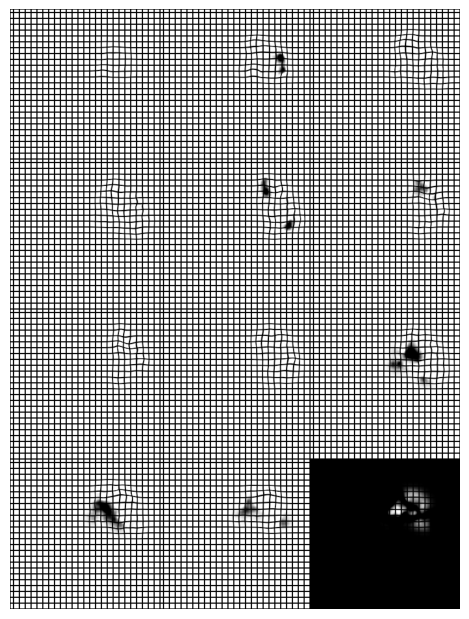

In [ ]:
# import ants

# # fixed_image = "../displacement-field/mask-images/I97386_masked.nii.gz"
# # displacement_field = "../displacement-field/temp_dis/1Warp.nii.gz"
# fixed_image = "/mnt/study-data/pgirardi/koedam/exps_pgirardi/reproduction/masked_images/I97386_mask_model.nii.gz"
# displacement_field = "/mnt/study-data/pgirardi/koedam/exps_pgirardi/reproduction/displacement-field/temp_dis/I97386_displacement-field.nii.gz1InverseWarp.nii.gz"

# fixed_image_ants = ants.image_read(fixed_image)

# warped_grid = ants.create_warped_grid(
#     image=fixed_image_ants, 
#     grid_step=10, 
#     grid_width=2, 
#     grid_directions=(True, True),
#     fixed_reference_image=fixed_image_ants, 
#     transform=[displacement_field],  # Aqui vai seu campo de deslocamento
#     foreground=1, 
#     background=0
# )

# # Plotar a grade deformada
# warped_grid.plot()

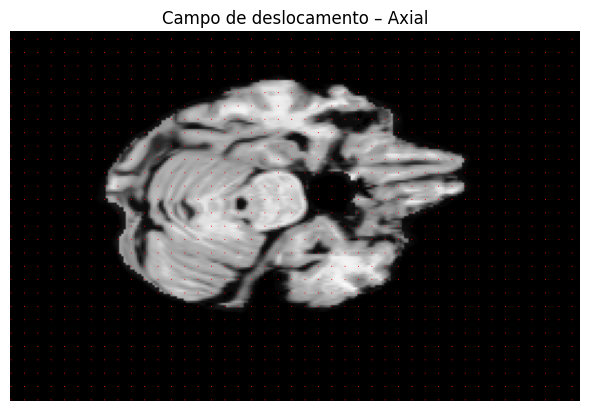

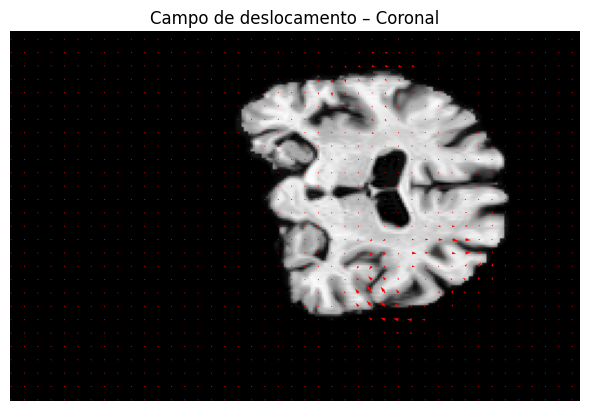

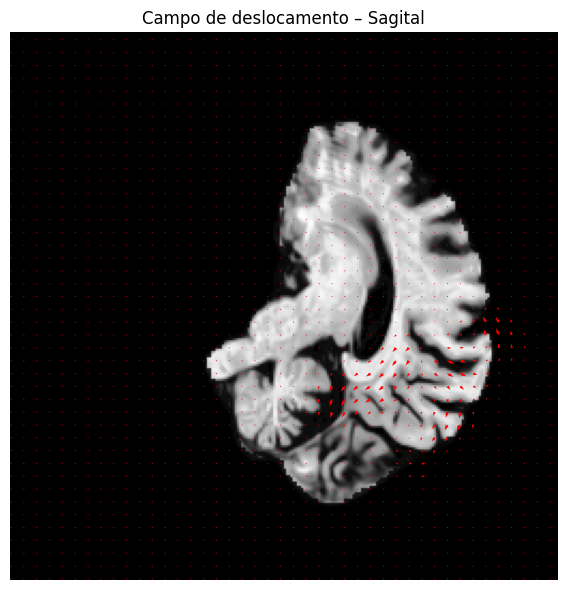

In [9]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

import ants
import numpy as np
import matplotlib.pyplot as plt

# =============================================================================
# CAMINHOS
# =============================================================================
FIXED_IMG_PATH = (
    "/mnt/databases/mri/adni/preproc/4-mni-hist-matching/"
    "I101191_stripped_nlm_denoised_biascorrected_mni_hist_match.nii.gz"
)

WARP_PATH = (
    "/mnt/study-data/pgirardi/koedam/"
    "exps_pgirardi/reproduction/displacement-field/temp_dis/"
    "I101191_displacement-field.nii.gz1Warp.nii.gz"
)

# =============================================================================
# PARÂMETROS DE VISUALIZAÇÃO
# =============================================================================
STEP = 6          # subamostragem espacial
VECTOR_SCALE = 1 # escala visual (não física)
VECTOR_WIDTH = 0.002

# =============================================================================
# CARREGAMENTO
# =============================================================================
fixed = ants.image_read(FIXED_IMG_PATH)
warp = ants.image_read(WARP_PATH)

fixed_np = fixed.numpy()
warp_np = warp.numpy()  # (X, Y, Z, 3)

# =============================================================================
# FUNÇÃO DE PLOT
# =============================================================================
def plot_slice(ref_slice, U, V, title):
    h, w = ref_slice.shape

    Y, X = np.mgrid[0:h:STEP, 0:w:STEP]

    plt.figure(figsize=(6, 6))
    plt.imshow(ref_slice, cmap="gray", origin="lower")

    plt.quiver(
        X, Y,
        U[::STEP, ::STEP],
        V[::STEP, ::STEP],
        color="red",
        angles="xy",
        scale_units="xy",
        scale=VECTOR_SCALE,
        width=VECTOR_WIDTH
    )

    plt.title(title)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

# =============================================================================
# FATIAS CENTRAIS
# =============================================================================
cx, cy, cz = np.array(fixed_np.shape) // 2

# -------------------------------------------------------------------------
# AXIAL (X, Y)
# -------------------------------------------------------------------------
ref_ax = fixed_np[:, :, cz]
Ux_ax = warp_np[:, :, cz, 0]
Uy_ax = warp_np[:, :, cz, 1]

plot_slice(ref_ax, Ux_ax, Uy_ax, "Campo de deslocamento – Axial")

# -------------------------------------------------------------------------
# CORONAL (X, Z)
# -------------------------------------------------------------------------
ref_cor = fixed_np[:, cy, :]
Ux_cor = warp_np[:, cy, :, 0]
Uz_cor = warp_np[:, cy, :, 2]

plot_slice(ref_cor, Ux_cor, Uz_cor, "Campo de deslocamento – Coronal")

# -------------------------------------------------------------------------
# SAGITAL (Y, Z)
# -------------------------------------------------------------------------
ref_sag = fixed_np[cx, :, :]
Uy_sag = warp_np[cx, :, :, 1]
Uz_sag = warp_np[cx, :, :, 2]

plot_slice(ref_sag, Uy_sag, Uz_sag, "Campo de deslocamento – Sagital")


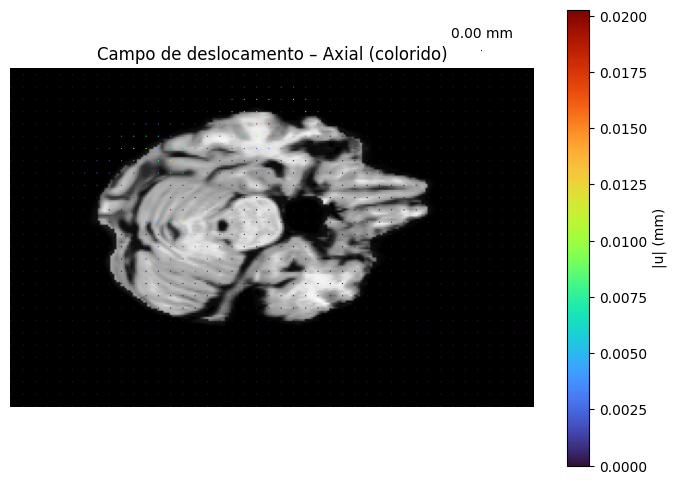

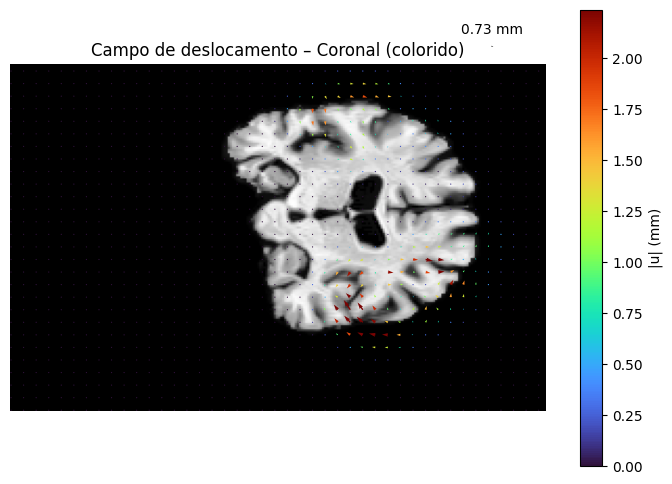

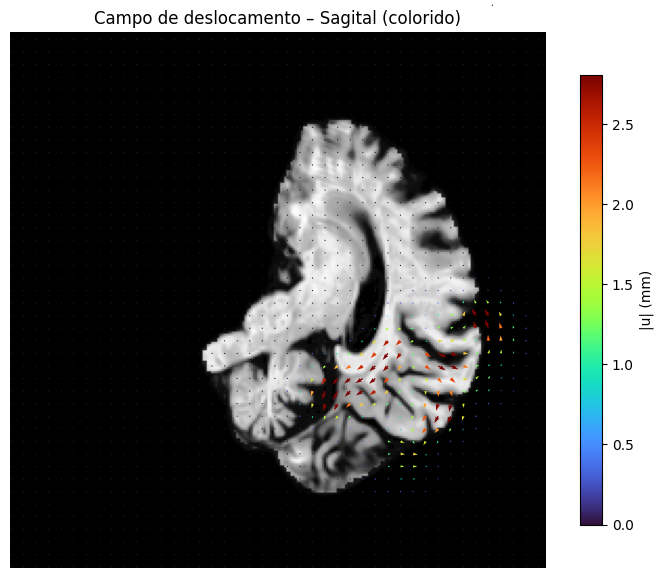

In [11]:
import matplotlib.colors as mcolors

# Visualização com setas coloridas pela magnitude
# e escala automática baseada no percentil 95 da magnitude.
def plot_quiver_colored(ref_slice, U, V, title, step=STEP):
    mag = np.sqrt(U**2 + V**2)
    mag_clip = np.clip(mag, None, np.percentile(mag, 99))

    h, w = ref_slice.shape
    Y, X = np.mgrid[0:h:step, 0:w:step]

    norm = mcolors.Normalize(vmin=mag_clip.min(), vmax=mag_clip.max())

    plt.figure(figsize=(7, 6))
    plt.imshow(ref_slice, cmap="gray", origin="lower")

    # Escala das setas: usa percentil 95 para evitar setas muito longas/curtas
    scale_val = np.percentile(mag_clip, 95) + 1e-6
    color_values = mag_clip[::step, ::step]

    q = plt.quiver(
        X,
        Y,
        U[::step, ::step],
        V[::step, ::step],
        color_values,
        cmap="turbo",
        norm=norm,
        angles="xy",
        scale_units="xy",
        scale=1.0 / scale_val,
        width=0.0025,
    )

    cb = plt.colorbar(q, shrink=0.8)
    cb.set_label("|u| (mm)")

    mag_ref = np.percentile(mag_clip, 90)
    plt.quiverkey(q, 0.9, 1.05, mag_ref, f"{mag_ref:.2f} mm", coordinates="axes")

    plt.title(title)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

# Exemplo de uso com as mesmas fatias centrais
plot_quiver_colored(ref_ax, Ux_ax, Uy_ax, "Campo de deslocamento – Axial (colorido)")
plot_quiver_colored(ref_cor, Ux_cor, Uz_cor, "Campo de deslocamento – Coronal (colorido)")
plot_quiver_colored(ref_sag, Uy_sag, Uz_sag, "Campo de deslocamento – Sagital (colorido)")


## Analisando atributos extraidos para conjunto de imagens

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis

# Carregar os dados
# file_path = '../displacement-field/csv-data/measures-data.csv'  # Substituir pelo caminho correto
file_path = '/mnt/study-data/pgirardi/koedam/exps_pgirardi/reproduction/measures-data.csv'
df = pd.read_csv(file_path)

# Informações básicas
display(df.info())
display(df.describe())

df.isnull().sum()  # Verificar valores ausentes

# Histogramas para distribuição das variáveis
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 12))
axes = axes.flatten()

cols = ["Mean Magnitude", "Root Mean Square", "JacobianDet Std", "Magnitude Variance", 
        "Mean JacobianDet", "Bending Energy"]

for i, col in enumerate(cols):
    sns.histplot(df[col], ax=axes[i], kde=True, bins=30)
    axes[i].set_title(f'Distribuição de {col}')

plt.tight_layout()
plt.show()

# Matriz de correlação
plt.figure(figsize=(10, 8))
sns.heatmap(df[cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Mapa de Correlação')
plt.show()

# Boxplots por Plane
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Plane', y='Mean Magnitude')
plt.title('Distribuição de Mean Magnitude por Plane')
plt.show()

# Scatter plot entre Mean JacobianDet e Bending Energy
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='Mean JacobianDet', y='Root Mean Square', hue='Plane')
plt.title('Relação entre Mean JacobianDet e Bending Energy')
plt.show()

# Identificação de outliers
for col in cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f'Outliers em {col}: {len(outliers)}')
